In [ ]:
!unzip "archive (2).zip" -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/images/slice-0.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/images/slice-1.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/images/slice-2.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/images/slice-3.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/mask-0/slice-0.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/mask-0/slice-1.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/mask-0/slice-2.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/mask-0/slice-3.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/mask-1/slice-0.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/mask-1/slice-1.png  
  inflating: dataset/LIDC-IDRI-slices/LIDC-IDRI-0947/nodule-3/mask-1/slice-2.png  
  inflating: dataset/LIDC-IDRI-slice

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf

In [ ]:
def load_nodule(nodule_path):
    image_folder = os.path.join(nodule_path, "images")
    mask_folders = [os.path.join(nodule_path, m)
                    for m in os.listdir(nodule_path) if "mask" in m]

    images = []
    masks = []

    image_files = sorted(os.listdir(image_folder))

    for img_file in image_files:
        img_path = os.path.join(image_folder, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        images.append(img)

        combined_mask = np.zeros_like(img)

        for mask_folder in mask_folders:
            mask_path = os.path.join(mask_folder, img_file)
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                combined_mask = np.maximum(combined_mask, mask)

        masks.append(combined_mask)

    return np.array(images), np.array(masks)


def normalize_images(images):
    images = images.astype(np.float32) / 255.0
    return images


def resize_images(images, masks, size=(128,128)):
    resized_images = []
    resized_masks = []

    for img, mask in zip(images, masks):
        img_resized = cv2.resize(img, size)
        mask_resized = cv2.resize(mask, size)

        resized_images.append(img_resized)
        resized_masks.append(mask_resized)

    return np.array(resized_images), np.array(resized_masks)

In [ ]:
dataset_path = "dataset/LIDC-IDRI-slices"  # change if needed

all_volumes = []
all_masks = []

for patient in os.listdir(dataset_path):
    patient_path = os.path.join(dataset_path, patient)

    if not os.path.isdir(patient_path):
        continue

    for nodule in os.listdir(patient_path):
        nodule_path = os.path.join(patient_path, nodule)

        if not os.path.isdir(nodule_path):
            continue

        try:
            images, masks = load_nodule(nodule_path)
            images = normalize_images(images)
            images, masks = resize_images(images, masks)

            all_volumes.append(images)
            all_masks.append(masks)

        except Exception as e:
            print("Skipping:", nodule_path, "Error:", e)

print("Total Nodules Loaded:", len(all_volumes))

Total Nodules Loaded: 2630


In [ ]:
TARGET_DEPTH = 8

def pad_depth(volume):
    depth = volume.shape[0]

    if depth >= TARGET_DEPTH:
        return volume[:TARGET_DEPTH]

    pad_before = (TARGET_DEPTH - depth) // 2
    pad_after = TARGET_DEPTH - depth - pad_before

    return np.pad(volume,
                  ((pad_before, pad_after), (0,0), (0,0)),
                  mode='constant')


X = np.array([pad_depth(v) for v in all_volumes])
Y = np.array([pad_depth(m) for m in all_masks])

# Add channel dimension
X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (2630, 8, 128, 128, 1)
Y shape: (2630, 8, 128, 128, 1)


In [ ]:
Y = (Y > 0).astype(np.float32)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (2104, 8, 128, 128, 1)
Val: (526, 8, 128, 128, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

def conv_block(x, filters):
    x = layers.Conv3D(filters, (3,3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv3D(filters, (3,3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x


inputs = layers.Input((8,128,128,1))

# Encoder
c1 = conv_block(inputs, 32)
p1 = layers.MaxPooling3D((1,2,2))(c1)

c2 = conv_block(p1, 64)
p2 = layers.MaxPooling3D((1,2,2))(c2)

# Bottleneck
c3 = conv_block(p2, 128)

# Decoder
u1 = layers.UpSampling3D((1,2,2))(c3)
u1 = layers.Concatenate()([u1, c2])
c4 = conv_block(u1, 64)

u2 = layers.UpSampling3D((1,2,2))(c4)
u2 = layers.Concatenate()([u2, c1])
c5 = conv_block(u2, 32)

outputs = layers.Conv3D(1, (1,1,1), activation="sigmoid")(c5)

model = tf.keras.Model(inputs, outputs)

In [ ]:
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_loss,
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 8, 128,    │        896 │ input_layer[0][0] │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 128,    │        128 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 8, 128,    │     27,680 │ activation[0][0]  │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128,    │        128 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 8, 64, 64, │          0 │ activation_1[0][… │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 8, 64, 64, │     55,360 │ max_pooling3d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        256 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 8, 64, 64, │    110,656 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        256 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 8, 32, 32, │          0 │ activation_3[0][… │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 8, 32, 32, │    221,312 │ max_pooling3d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 32, 32, │        512 │ conv3d_4[0][0]  

 Total params: 1,414,145 (5.39 MB)

 Trainable params: 1,412,865 (5.39 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=6,
    batch_size=4
)

Epoch 1/6
526/526 ━━━━━━━━━━━━━━━━━━━━ 316s 540ms/step - accuracy: 0.7409 - loss: 0.9798 - val_accuracy: 0.9219 - val_loss: 0.9757
Epoch 2/6
526/526 ━━━━━━━━━━━━━━━━━━━━ 284s 540ms/step - accuracy: 0.9389 - loss: 0.9695 - val_accuracy: 0.9756 - val_loss: 0.9579
Epoch 3/6
526/526 ━━━━━━━━━━━━━━━━━━━━ 284s 540ms/step - accuracy: 0.9669 - loss: 0.9484 - val_accuracy: 0.9901 - val_loss: 0.9211
Epoch 4/6
526/526 ━━━━━━━━━━━━━━━━━━━━ 284s 541ms/step - accuracy: 0.9878 - loss: 0.9062 - val_accuracy: 0.9919 - val_loss: 0.8492
Epoch 5/6
526/526 ━━━━━━━━━━━━━━━━━━━━ 285s 541ms/step - accuracy: 0.9936 - loss: 0.7805 - val_accuracy: 0.9906 - val_loss: 0.7424
Epoch 6/6
526/526 ━━━━━━━━━━━━━━━━━━━━ 284s 541ms/step - accuracy: 0.9964 - loss: 0.6402 - val_accuracy: 0.9974 - val_loss: 0.6190


In [ ]:
print("Total samples:", X.shape[0])

Total samples: 2630


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Save full trained baseline model
model.save("/content/drive/MyDrive/lung_segmentation_baseline.h5")

print("Baseline model saved successfully!")

Baseline model saved successfully!


In [ ]:
import pickle

with open("/content/drive/MyDrive/baseline_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved!")

Training history saved!


In [ ]:
### If needed to be reloaded
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/lung_segmentation_baseline.h5",
    custom_objects={
        "dice_loss": dice_loss,
        "dice_coefficient": dice_coefficient
    }
)

print("Model reloaded successfully!")

Model reloaded successfully!


In [ ]:
import numpy as np

def compute_dice(y_true, y_pred):
    smooth = 1e-6
    y_true_f = y_true.flatten()
    y_pred_f = (y_pred > 0.5).astype(np.float32).flatten()

    intersection = np.sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        np.sum(y_true_f) + np.sum(y_pred_f) + smooth
    )


def compute_iou(y_true, y_pred):
    smooth = 1e-6
    y_true_f = y_true.flatten()
    y_pred_f = (y_pred > 0.5).astype(np.float32).flatten()

    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)


# Predict validation data
predictions = model.predict(X_val)

dice_scores = []
iou_scores = []

for i in range(len(X_val)):
    dice_scores.append(compute_dice(Y_val[i], predictions[i]))
    iou_scores.append(compute_iou(Y_val[i], predictions[i]))

print("Average Dice Score:", np.mean(dice_scores))
print("Average IoU Score:", np.mean(iou_scores))

17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 816ms/step
Average Dice Score: 0.422321
Average IoU Score: 0.3330147


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


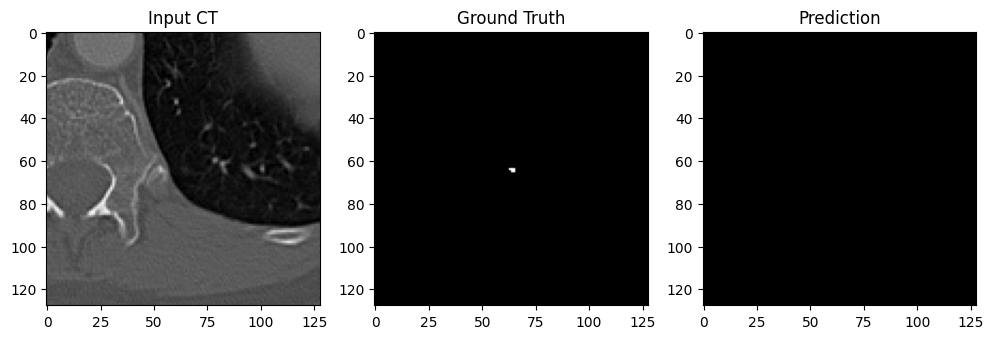

In [ ]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, len(X_val)-1)

sample = X_val[idx:idx+1]
prediction = model.predict(sample)

mid_slice = sample.shape[1] // 2

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input CT")
plt.imshow(sample[0, mid_slice, :, :, 0], cmap="gray")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(Y_val[idx, mid_slice, :, :, 0], cmap="gray")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(prediction[0, mid_slice, :, :, 0] > 0.5, cmap="gray")

plt.show()

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


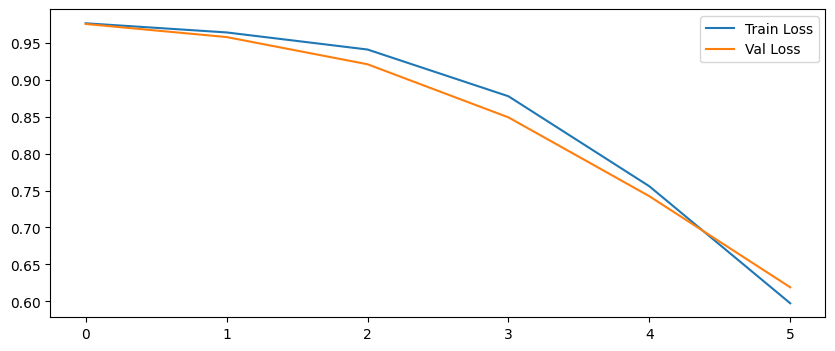

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

model_aug = load_model(
    "/content/drive/MyDrive/lung_segmentation_augmented.h5",
    custom_objects={
        "dice_loss": dice_loss,
        "dice_coefficient": dice_coefficient
    }
)

print("Augmented model reloaded successfully!")

NameError: name 'dice_loss' is not defined